In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Business Understanding

**Goal:** predict a software developer's annual salary in USD using details such as country,
role, education and work experience. The prediction will be used in a salary comparison web app.

This is a **supervised regression** problem because `ConvertedCompYearly` is a continuous number.
The data comes from the Stack Overflow Annual Developer Survey (`results.csv`).

The main evaluation metric is **Mean Absolute Error (MAE)**. It shows the average prediction error
in dollars, which is easy for a user to understand.


# 2. Data Understanding

## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
## low_memory=False is used because the survey has many mixed-type columns
FILE_PATH = "results.csv"
df = pd.read_csv(FILE_PATH, low_memory=False)

## Set the target column
col_y = 'ConvertedCompYearly'

print('Number of records:', len(df))
print('Number of columns:', len(df.columns))
df.head()

Number of records: 49191
Number of columns: 172


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


The survey contains many columns, but only the columns that could reasonably affect salary are
selected. These are also details that a user can enter in the web app.


In [3]:
## Select the columns that are relevant to predicting salary
col_selected = ['Employment',          ## Used to keep only people who actually earn a salary
                'Country',             ## Pay differs hugely between labour markets
                'Age',                 ## Rough proxy for career stage
                'EdLevel',             ## Formal education level
                'DevType',             ## The role(s) the respondent performs
                'OrgSize',             ## Larger companies usually pay more
                'ICorPM',              ## Individual contributor or people manager
                'RemoteWork',          ## Remote, hybrid or in-person
                'Industry',            ## The sector the company operates in
                'PurchaseInfluence',   ## Proxy for seniority / decision-making power
                'NewRole',             ## Whether they recently changed job
                'WorkExp',             ## Years of professional work experience
                'YearsCode',           ## Total years of coding
                'ToolCountWork',       ## Number of tools used at work
                'ToolCountPersonal',   ## Number of tools used personally
                col_y]                 ## Target: yearly compensation in USD

df = df[col_selected].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employment           48339 non-null  object 
 1   Country              35437 non-null  object 
 2   Age                  49191 non-null  object 
 3   EdLevel              48149 non-null  object 
 4   DevType              43680 non-null  object 
 5   OrgSize              34178 non-null  object 
 6   ICorPM               33243 non-null  object 
 7   RemoteWork           33780 non-null  object 
 8   Industry             33642 non-null  object 
 9   PurchaseInfluence    37437 non-null  object 
 10  NewRole              35527 non-null  object 
 11  WorkExp              42893 non-null  float64
 12  YearsCode            43042 non-null  float64
 13  ToolCountWork        27611 non-null  float64
 14  ToolCountPersonal    25582 non-null  float64
 15  ConvertedCompYearly  23947 non-null 

## 2.2 Summary Statistics

In [4]:
## Understand the type of variable for each column
df.describe(include='all')

,Employment,Country,Age,EdLevel,DevType,OrgSize,ICorPM,RemoteWork,Industry,PurchaseInfluence,NewRole,WorkExp,YearsCode,ToolCountWork,ToolCountPersonal,ConvertedCompYearly
count,48339,35437,49191,48149,43680,34178,33243,33780,33642,37437,35527,42893.000000,43042.000000,27611.000000,25582.000000,2.394700e+04
unique,6,177,7,8,32,9,2,5,15,5,5,NaN,NaN,NaN,NaN,NaN
top,Employed,United States of America,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Developer, full-stack",20 to 99 employees,Individual contributor,Remote,Software Development,No,I have neither consider or transitioned into a...,NaN,NaN,NaN,NaN,NaN
freq,33750,7233,16519,20278,12351,6688,28341,10931,16282,19697,16205,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.367403,16.570861,17.734852,8.545579,1.017615e+05
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.800117,11.787610,269.810134,44.664738,4.617569e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,0.000000,1.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,8.000000,4.000000,3.000000,3.817100e+04
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,14.000000,6.000000,5.000000,7.532000e+04
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,24.000000,10.000000,7.000000,1.205960e+05


In [5]:
## Check for missing data
missing_values = df.isna().sum()
missing_percentage = (df.isna().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing values': missing_values,
    'Missing percentage': missing_percentage
})

missing_summary


,Missing values,Missing percentage
Employment,852,1.73
Country,13754,27.96
Age,0,0.00
EdLevel,1042,2.12
DevType,5511,11.20
OrgSize,15013,30.52
ICorPM,15948,32.42
RemoteWork,15411,31.33
Industry,15549,31.61
PurchaseInfluence,11754,23.89


About half of the salary values are missing, so those rows cannot be used for training.

The experience and tool-count columns need to be converted to numbers before modelling.


In [6]:
## Describe data distribution of the target
df[col_y].describe()

count    2.394700e+04
mean     1.017615e+05
std      4.617569e+05
min      1.000000e+00
25%      3.817100e+04
50%      7.532000e+04
75%      1.205960e+05
max      5.000000e+07
Name: ConvertedCompYearly, dtype: float64

The mean is much higher than the median and the maximum is very large. This shows that salary is
right-skewed and contains some extreme values.


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

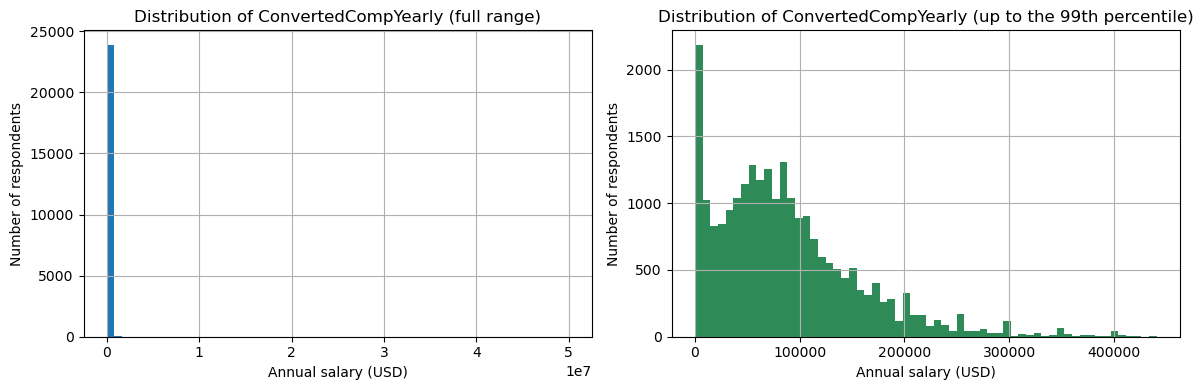

99th percentile: USD 440,856
Maximum:         USD 50,000,000


In [7]:
## Understanding distribution of target
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

## Full range: a few extreme salaries stretch the axis so far that everyone else
## is squeezed into the first bar
df[col_y].hist(bins=60, ax=ax[0])
ax[0].set_title('Distribution of ConvertedCompYearly (full range)')
ax[0].set_xlabel('Annual salary (USD)')
ax[0].set_ylabel('Number of respondents')

## Same data, but the axis is limited to the 99th percentile so the shape is visible
limit = df[col_y].quantile(0.99)
df[df[col_y] <= limit][col_y].hist(bins=60, ax=ax[1], color='seagreen')
ax[1].set_title('Distribution of ConvertedCompYearly (up to the 99th percentile)')
ax[1].set_xlabel('Annual salary (USD)')
ax[1].set_ylabel('Number of respondents')

plt.tight_layout()
plt.show()

print(f'99th percentile: USD {limit:,.0f}')
print(f'Maximum:         USD {df[col_y].max():,.0f}')

The full histogram is difficult to read because a few very large values stretch the x-axis.
Limiting the second plot to the 99th percentile makes the main salary distribution clearer.

MAE will be used as the main metric because RMSE gives much more weight to large errors.


### 2.3.1.2 Understanding distribution of features

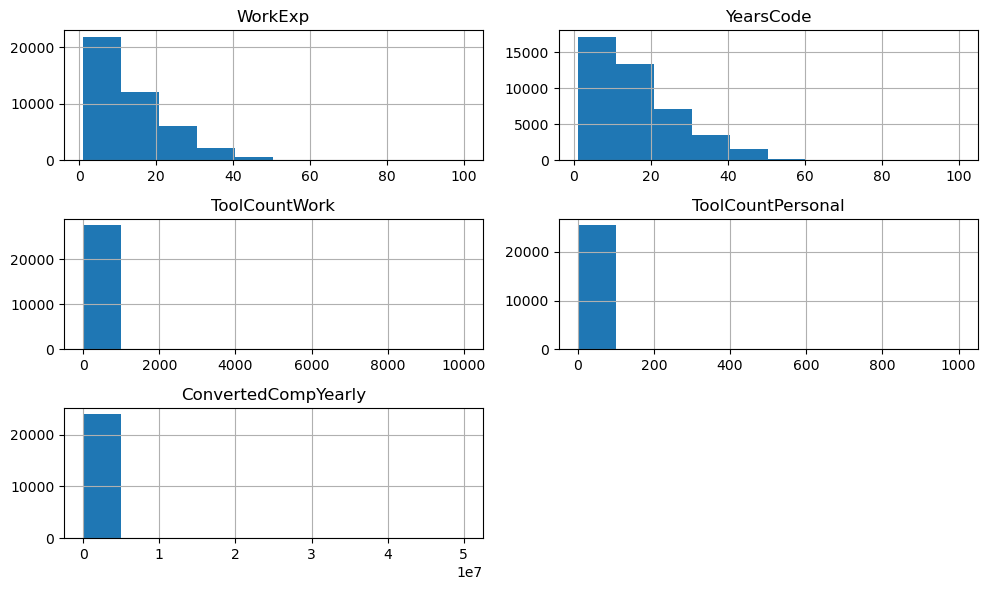

In [8]:
## Convert numeric-looking columns for plotting
df_numeric = df.copy()

for col in ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal']:
    df_numeric[col] = df_numeric[col].replace({
        'Less than 1 year': 0.5,
        'More than 50 years': 51
    })
    df_numeric[col] = pd.to_numeric(df_numeric[col], errors='coerce')

df_numeric.hist(figsize=(10, 6))
plt.tight_layout()
plt.show()


In [9]:
## Check the categorical columns
col_categorical = df.select_dtypes(include=['object']).columns

for col in col_categorical:
    print(f'{col} ({df[col].nunique()}): {df[col].unique()[:8]}')
    print()


Employment (6): ['Employed' 'Independent contractor, freelancer, or self-employed'
 'Student' 'Retired' 'Not employed' 'I prefer not to say' nan]

Country (177): ['Ukraine' 'Netherlands' 'India' 'Georgia' 'Australia' 'Greece' 'Germany'
 'Bangladesh']

Age (7): ['25-34 years old' '35-44 years old' '45-54 years old' '18-24 years old'
 '65 years or older' '55-64 years old' 'Prefer not to say']

EdLevel (8): ['Master’s degree (M.A., M.S., M.Eng., MBA, etc.)'
 'Associate degree (A.A., A.S., etc.)'
 'Bachelor’s degree (B.A., B.S., B.Eng., etc.)'
 'Some college/university study without earning a degree'
 'Professional degree (JD, MD, Ph.D, Ed.D, etc.)'
 'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)'
 'Other (please specify):' 'Primary/elementary school']

DevType (32): ['Developer, mobile' 'Developer, back-end' 'Developer, front-end'
 'Engineering manager' 'Developer, full-stack'
 'Architect, software or solutions' 'Data engineer'
 'Financial analyst or e

`Country`, `Industry` and `DevType` contain many categories. Rare categories will be grouped later
so that one-hot encoding does not create too many columns with very little data.


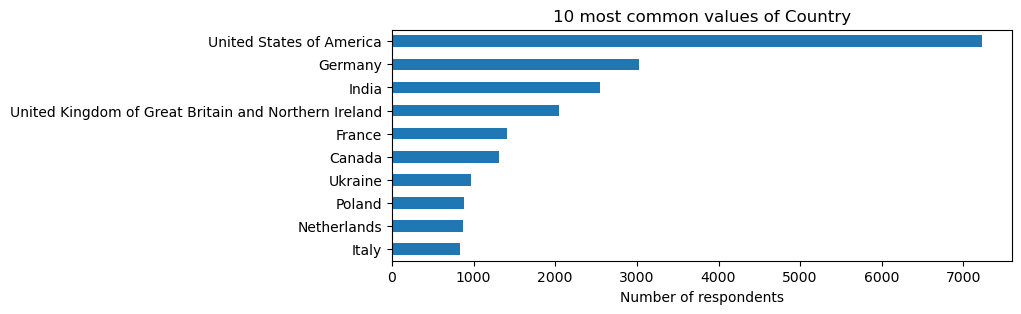

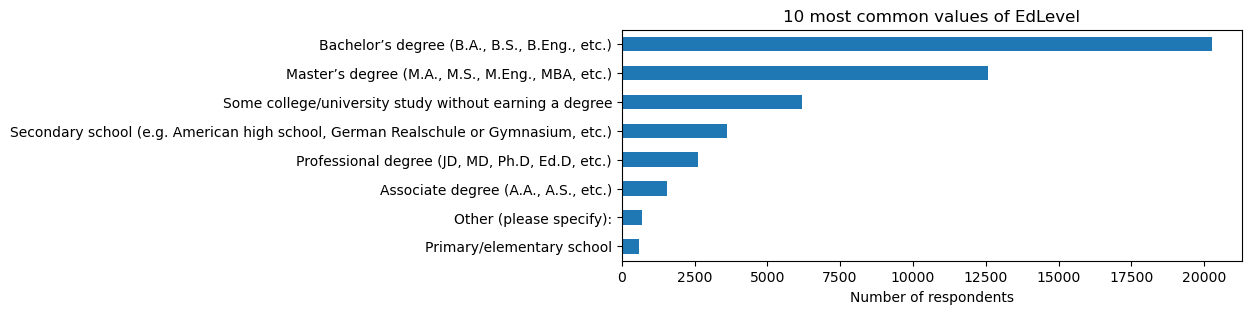

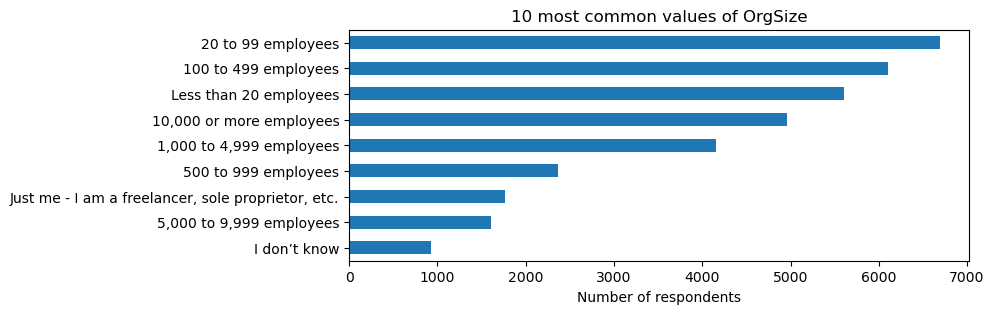

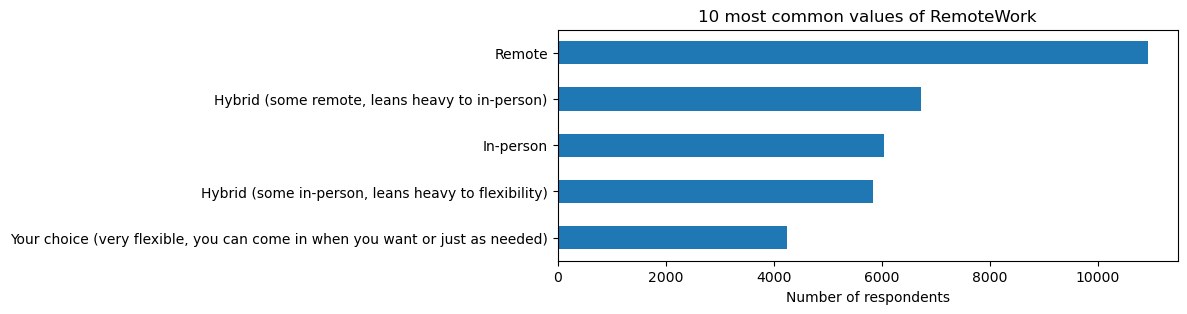

In [10]:
## Understanding distribution of the most common categories
for col in ['Country', 'EdLevel', 'OrgSize', 'RemoteWork']:
    df[col].value_counts().head(10).plot(kind='barh', figsize=(8, 3))
    plt.title(f'10 most common values of {col}')
    plt.xlabel('Number of respondents')
    plt.ylabel('')
    plt.gca().invert_yaxis()
    plt.show()

Most responses come from a small number of countries. The model should therefore be more reliable
for countries with more survey responses.


### 2.3.2 Understanding relationship between variables

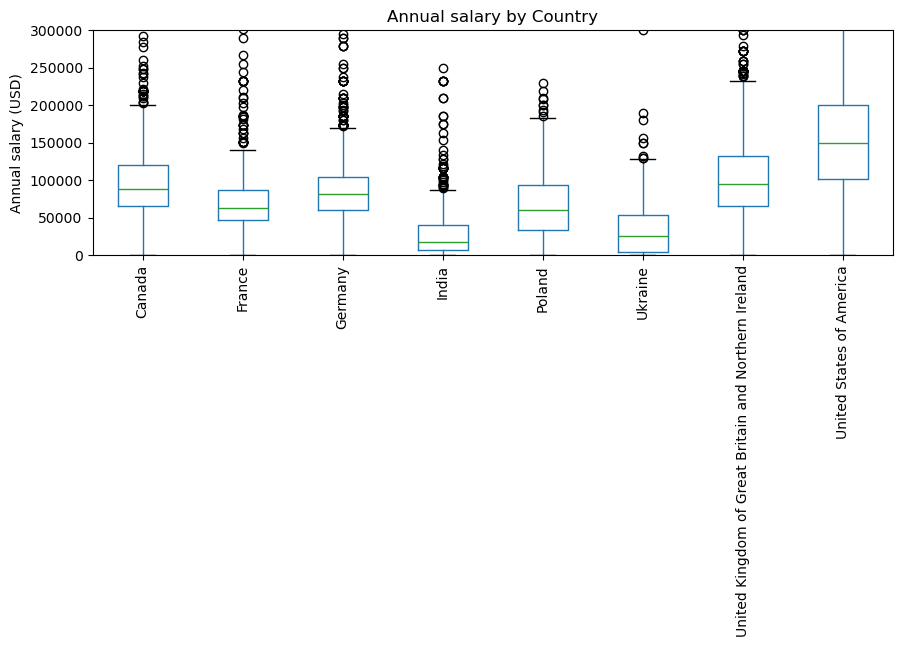

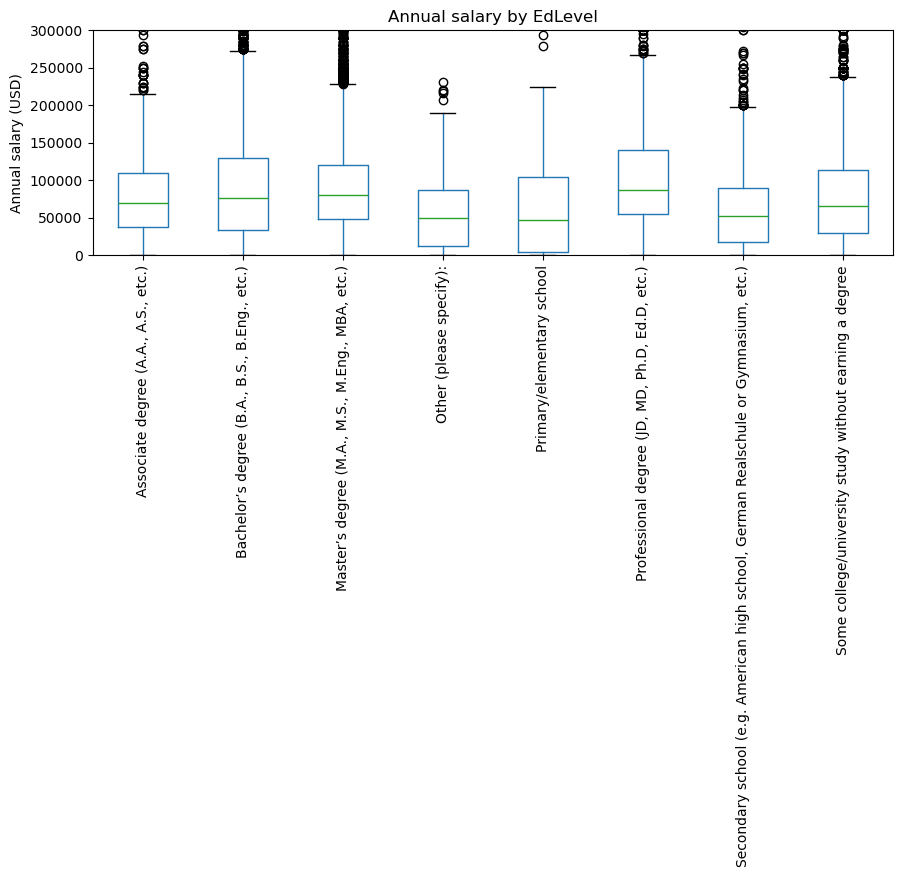

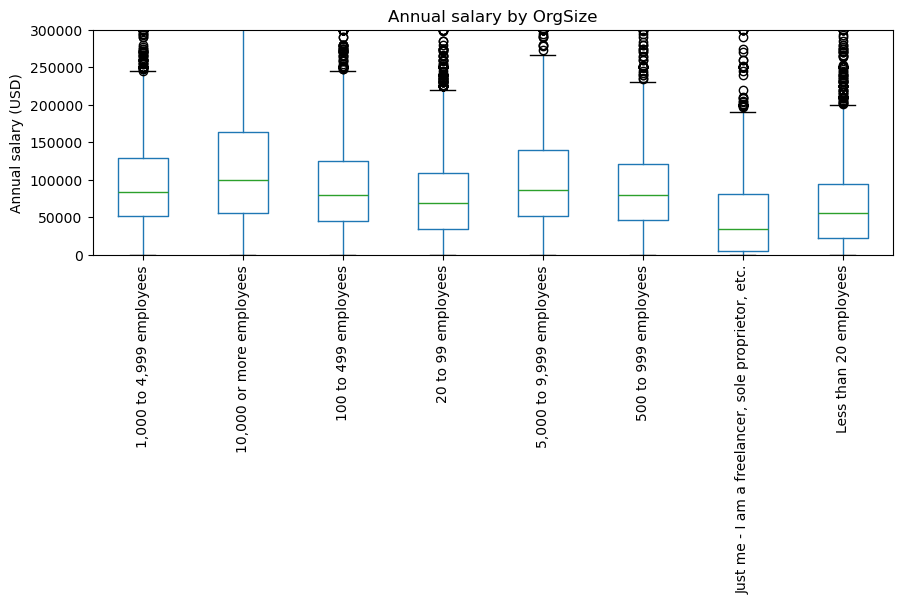

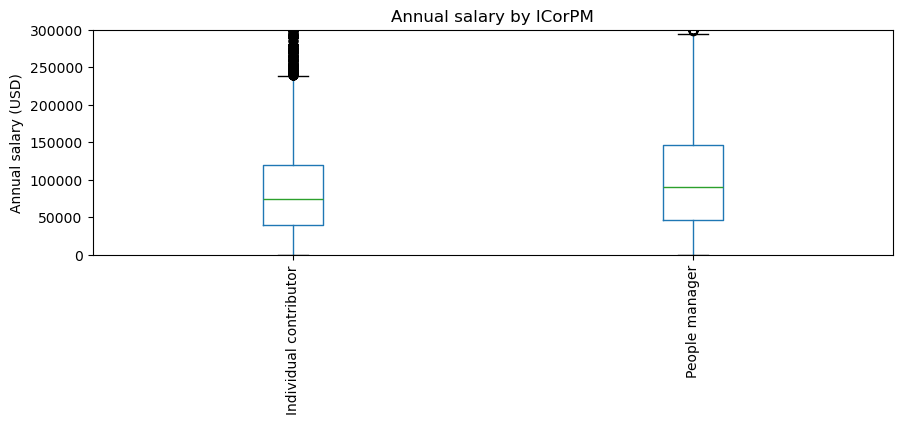

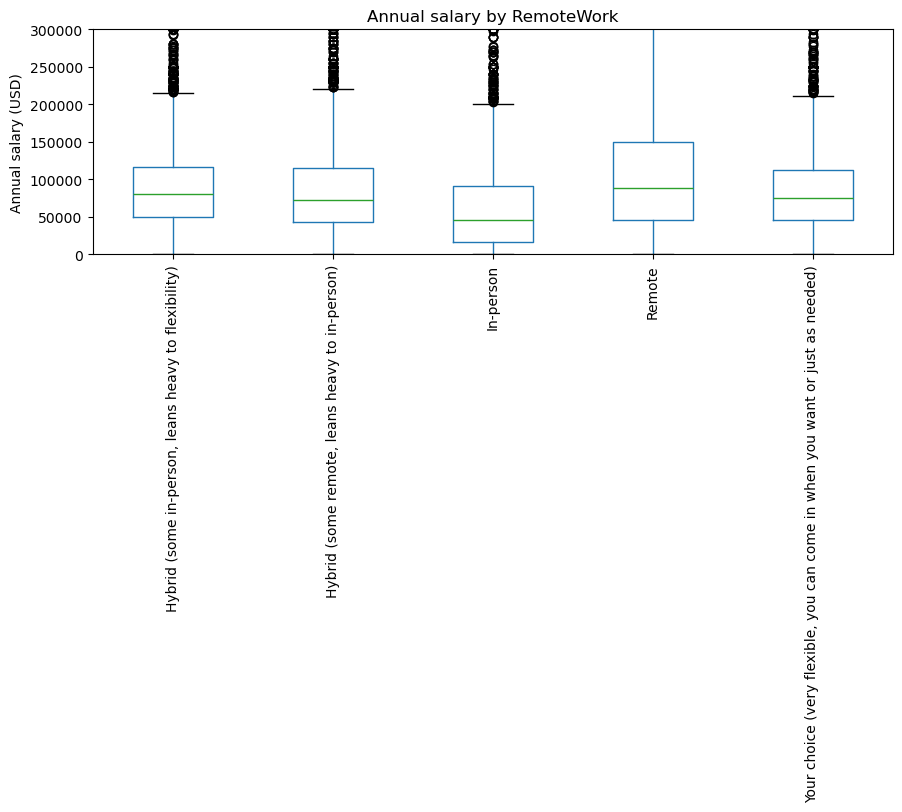

In [11]:
## Understanding relationship between variables
## Salary against each categorical feature, limited to the 8 most common values so the plot stays readable
for col in ['Country', 'EdLevel', 'OrgSize', 'ICorPM', 'RemoteWork']:
    top_values = df[col].value_counts().head(8).index

    df[df[col].isin(top_values)].boxplot(column=col_y, by=col, grid=False, rot=90, figsize=(10, 3))
    plt.title(f'Annual salary by {col}')
    plt.suptitle('')
    plt.xlabel('')
    plt.ylabel('Annual salary (USD)')
    plt.ylim(0, 300000)
    plt.show()

Country shows the clearest difference in salary. Organisation size and whether the respondent is
an individual contributor or manager also appear useful, so these features will be kept.


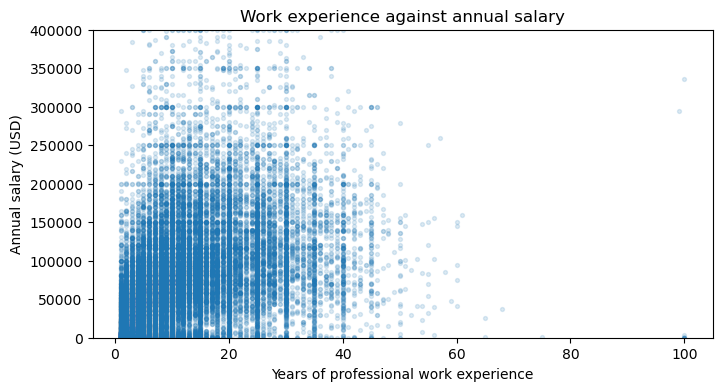

In [12]:
## Relationship between work experience and salary
plt.figure(figsize=(8, 4))
plt.scatter(df_numeric['WorkExp'], df_numeric[col_y], alpha=0.15, s=8)
plt.title('Work experience against annual salary')
plt.xlabel('Years of professional work experience')
plt.ylabel('Annual salary (USD)')
plt.ylim(0, 400000)
plt.show()

Salary generally increases with work experience, but there is still a wide spread at each
experience level. Other features are needed together with experience.


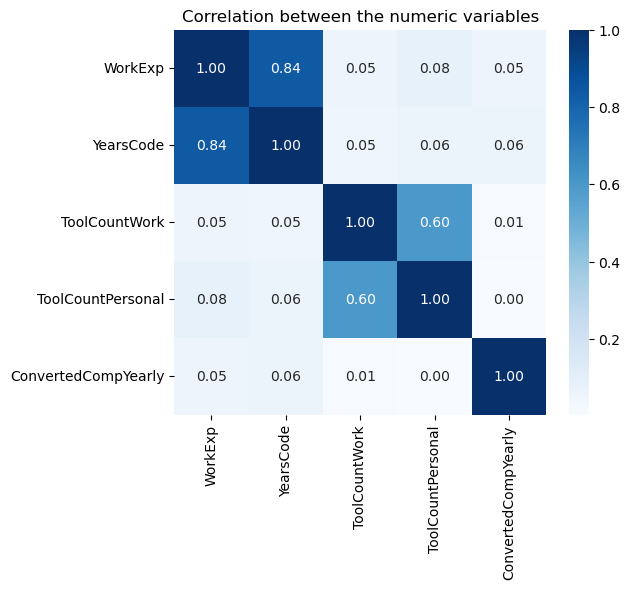

In [13]:
## Correlation between the numeric variables
plt.figure(figsize=(6, 5))
sns.heatmap(df_numeric.select_dtypes(include=['float64', 'int64']).corr(),
            annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation between the numeric variables')
plt.show()

`WorkExp` and `YearsCode` have a strong correlation because they both measure experience.
Their individual correlations with salary are much lower, so the categorical features may also
contain important information.


# 3. Data Preparation

## 3.1 Data Cleaning

In [14]:
## Keep employed respondents with a known salary
print('Records before cleaning:', len(df))

df = df[df['Employment'] == 'Employed'].copy()
print('After keeping employed respondents only:', len(df))

df[col_y] = pd.to_numeric(df[col_y], errors='coerce')
df = df[df[col_y].notna()].copy()
print('After dropping rows with no salary:', len(df))


Records before cleaning: 49191
After keeping employed respondents only: 33750
After dropping rows with no salary: 19500


### Checking the largest salary values

A few very large salaries may have a strong effect on models that use squared error. The table
below checks how much of the total squared deviation comes from the largest records.


In [15]:
## Check the influence of the largest salaries
deviation_squared = (df[col_y] - df[col_y].median()) ** 2
largest_records = [1, 3, 10, 20, 100]

error_percentage = []
for number in largest_records:
    largest_error = deviation_squared.nlargest(number).sum()
    error_percentage.append(largest_error / deviation_squared.sum() * 100)

influence = pd.DataFrame({
    'Largest records': largest_records,
    'Percentage of all records': np.array(largest_records) / len(df) * 100,
    'Percentage of total squared error': error_percentage
})

influence.round(2)


,Largest records,Percentage of all records,Percentage of total squared error
0,1,0.01,48.31
1,3,0.02,72.92
2,10,0.05,92.16
3,20,0.10,93.21
4,100,0.51,95.17


In [16]:
## The largest salaries, with the country they were reported from
df.nlargest(8, col_y)[['Country', col_y]]

,Country,ConvertedCompYearly
28700,Ukraine,33552715.0
43143,Poland,18387548.0
35353,"Iran, Islamic Republic of...",15430267.0
45971,Netherlands,13921760.0
24900,India,9531653.0
10025,United States of America,9000000.0
30728,Brazil,6371285.0
40418,Viet Nam,6000000.0


The largest salary records make up a very small part of the dataset but a large part of the
squared deviation. Several also come from countries where a local-currency value may have been
entered as USD.

Instead of using an IQR rule, a fixed range is used. An IQR rule would remove many valid high
salaries because salary is strongly skewed and combines countries with very different pay levels.

This model will cover annual salaries from USD 1,000 to USD 2,000,000. This removes 407 values
below the model's range and 10 unusually large values above it.


In [17]:
## Keep salaries inside the range covered by this model
SALARY_FLOOR = 1_000
SALARY_CEILING = 2_000_000

print('Salaries below the floor:  ', (df[col_y] < SALARY_FLOOR).sum())
print('Salaries above the ceiling:', (df[col_y] > SALARY_CEILING).sum())

salary_in_range = (
    (df[col_y] >= SALARY_FLOOR) &
    (df[col_y] <= SALARY_CEILING)
)

df = df[salary_in_range].copy()
print(f'After keeping salaries between USD {SALARY_FLOOR:,} and USD {SALARY_CEILING:,}:', len(df))


Salaries below the floor:   407
Salaries above the ceiling: 10
After keeping salaries between USD 1,000 and USD 2,000,000: 19083


In [18]:
## Convert experience and tool-count columns to numbers
col_numeric = ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal']

for col in col_numeric:
    df[col] = df[col].replace({
        'Less than 1 year': 0.5,
        'More than 50 years': 51
    })
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Keep experience inside the range covered by this model
EXPERIENCE_MAX = 50

print('YearsCode above the limit:', (df['YearsCode'] > EXPERIENCE_MAX).sum())
print('WorkExp above the limit:  ', (df['WorkExp'] > EXPERIENCE_MAX).sum())

over_experience_limit = (
    (df['YearsCode'] > EXPERIENCE_MAX) |
    (df['WorkExp'] > EXPERIENCE_MAX)
)

df = df[~over_experience_limit].copy()
print(f'After keeping experience within {EXPERIENCE_MAX} years:', len(df))

df.info()


YearsCode above the limit: 29
WorkExp above the limit:   9
After keeping experience within 50 years: 19052
<class 'pandas.core.frame.DataFrame'>
Index: 19052 entries, 0 to 49122
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Employment           19052 non-null  object 
 1   Country              19052 non-null  object 
 2   Age                  19052 non-null  object 
 3   EdLevel              19039 non-null  object 
 4   DevType              19052 non-null  object 
 5   OrgSize              19039 non-null  object 
 6   ICorPM               18767 non-null  object 
 7   RemoteWork           18958 non-null  object 
 8   Industry             19022 non-null  object 
 9   PurchaseInfluence    19019 non-null  object 
 10  NewRole              19012 non-null  object 
 11  WorkExp              18859 non-null  float64
 12  YearsCode            18983 non-null  float64
 13  ToolCountWork        16263 non-nul

In [19]:
## Fill missing values
for col in col_numeric:
    df[col] = df[col].fillna(df[col].median())

col_categorical = df.select_dtypes(include=['object']).columns
for col in col_categorical:
    df[col] = df[col].fillna('Unknown')

df.isna().sum()


Employment             0
Country                0
Age                    0
EdLevel                0
DevType                0
OrgSize                0
ICorPM                 0
RemoteWork             0
Industry               0
PurchaseInfluence      0
NewRole                0
WorkExp                0
YearsCode              0
ToolCountWork          0
ToolCountPersonal      0
ConvertedCompYearly    0
dtype: int64

Missing numeric values are filled with the median, while missing categorical values are labelled
as `'Unknown'`. This keeps rows that still contain useful information.

The salary and experience limits are fixed model boundaries rather than a general outlier rule.
Unusual values inside those boundaries are kept.


## 3.2 Feature Engineering

Three new features are created:

1. `PrimaryDevType` keeps the first developer role if multiple roles are ever listed. In this
   survey version, the existing role values are already single entries.
2. `ToolCountTotal` adds the work and personal tool counts.
3. `CodingBeforeWork` estimates how many years a respondent coded before starting work.

Rare country, industry and role values are grouped as `'Other'`.


In [20]:
## 1. Keep only the first listed role, to turn DevType into a usable feature
df['PrimaryDevType'] = df['DevType'].astype(str).str.split(';').str[0].str.strip()

## 2. Total tooling exposure
df['ToolCountTotal'] = df['ToolCountWork'] + df['ToolCountPersonal']

## 3. Years spent coding before starting professional work
df['CodingBeforeWork'] = (df['YearsCode'] - df['WorkExp']).clip(lower=0)

df[['DevType', 'PrimaryDevType', 'ToolCountWork', 'ToolCountPersonal',
    'ToolCountTotal', 'YearsCode', 'WorkExp', 'CodingBeforeWork']].head()

,DevType,PrimaryDevType,ToolCountWork,ToolCountPersonal,ToolCountTotal,YearsCode,WorkExp,CodingBeforeWork
0,"Developer, mobile","Developer, mobile",7.0,3.0,10.0,14.0,8.0,6.0
1,"Developer, back-end","Developer, back-end",6.0,5.0,11.0,10.0,2.0,8.0
3,"Developer, back-end","Developer, back-end",7.0,4.0,11.0,5.0,4.0,1.0
7,"Architect, software or solutions","Architect, software or solutions",10.0,10.0,20.0,30.0,22.0,8.0
8,Data engineer,Data engineer,7.0,4.0,11.0,15.0,9.0,6.0


In [21]:
## Group rare categories into 'Other'
col_limit = {'Country': 20, 'Industry': 15, 'PrimaryDevType': 15}

for col in col_limit:
    limit = col_limit[col]
    print(f'{col}: {df[col].nunique()} values before grouping')

    top_values = df[col][df[col] != 'Other'].value_counts().head(limit).index
    df[col] = df[col].where(df[col].isin(top_values), 'Other')

    print(f'{col}: {df[col].nunique()} values after grouping')
    print()


Country: 151 values before grouping
Country: 21 values after grouping

Industry: 16 values before grouping
Industry: 16 values after grouping

PrimaryDevType: 31 values before grouping
PrimaryDevType: 16 values after grouping



In [22]:
## Select the final features
col_x_numeric = ['WorkExp', 'YearsCode', 'ToolCountWork', 'ToolCountPersonal',
                 'ToolCountTotal', 'CodingBeforeWork']

col_x_categorical = ['Country', 'Age', 'EdLevel', 'PrimaryDevType', 'OrgSize',
                     'ICorPM', 'RemoteWork', 'Industry', 'PurchaseInfluence', 'NewRole']

col_x = col_x_numeric + col_x_categorical

## Save the valid choices for the web app and unseen data
col_options = {}
for col in col_x_categorical:
    col_options[col] = sorted(df[col].unique().tolist())

x = df[col_x].copy()
y = df[col_y].copy()

## One-hot encode categorical features
for col in col_x_categorical:
    x[col] = pd.Categorical(x[col], categories=col_options[col])

x = pd.get_dummies(x, drop_first=True, dtype=int)

print('Number of features before encoding:', len(col_x))
print('Number of features after encoding:', x.shape[1])
x.head()


Number of features before encoding: 16
Number of features after encoding: 96


,WorkExp,YearsCode,ToolCountWork,ToolCountPersonal,ToolCountTotal,CodingBeforeWork,Country_Austria,Country_Brazil,Country_Canada,Country_Czech Republic,...,PurchaseInfluence_Unknown,"PurchaseInfluence_Yes, I endorsed a tool that was open-source and is currently used by more than just myself but no purchase was made","PurchaseInfluence_Yes, I endorsed a tool that was ultimately not purchased or used at my organization","PurchaseInfluence_Yes, I influenced the purchase of a substantial addition to the tech stack","PurchaseInfluence_Yes, I influenced the purchase of a tool that more than five colleagues use but it is not a substantial addition to the tech stack",NewRole_I have somewhat considered changing my career and/or the industry I work in,NewRole_I have strongly considered changing my career and/or the industry I work in,NewRole_I have transitioned into a new career and/or industry involuntarily,NewRole_I have transitioned into a new career and/or industry voluntarily,NewRole_Unknown
0,8.0,14.0,7.0,3.0,10.0,6.0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,2.0,10.0,6.0,5.0,11.0,8.0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,4.0,5.0,7.0,4.0,11.0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,22.0,30.0,10.0,10.0,20.0,8.0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
8,9.0,15.0,7.0,4.0,11.0,6.0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


## 3.3 Train-Test Split

In [23]:
## Split data into train set and test set
from sklearn.model_selection import train_test_split

test_size = 0.2
random_state = 67
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=test_size, random_state=random_state)

print('Training records:', len(x_train))
print('Testing records:', len(x_test))

Training records: 15241
Testing records: 3811


# 4. Modelling

Four regression models are trained and tested on the same data:

| Model | Reason for using it |
|---|---|
| Linear Regression | Simple baseline model |
| Decision Tree Regressor | Can learn non-linear patterns |
| Random Forest Regressor | Averages many decision trees |
| Gradient Boosting Regressor | Builds trees that correct earlier errors |


## 4.1 Linear Regression

In [24]:
## Initialise and train model
from sklearn.linear_model import LinearRegression

linr = LinearRegression()
linr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
## Evaluate model
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score

## A straight line can predict below zero, which is impossible for a salary,
## so any negative prediction is floored at 0
y_pred_linr = np.maximum(linr.predict(x_test), 0)

print('Linear Regression')
print(f'MAE: {mean_absolute_error(y_test, y_pred_linr)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_linr)}')
print(f'R2: {r2_score(y_test, y_pred_linr)}')

Linear Regression
MAE: 38061.826813291016
RMSE: 76154.22405605337
R2: 0.382380615974093


## 4.2 Decision Tree Regressor

In [26]:
## Initialise and train model
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=random_state)
tree.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",67
,"max_l

In [27]:
## Evaluate model
y_pred_tree = tree.predict(x_test)

print('Decision Tree Regressor')
print(f'MAE: {mean_absolute_error(y_test, y_pred_tree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_tree)}')
print(f'R2: {r2_score(y_test, y_pred_tree)}')

Decision Tree Regressor
MAE: 53803.68171083705
RMSE: 108135.47305447233
R2: -0.245286534507847


## 4.3 Random Forest Regressor

In [28]:
## Initialise and train model
from sklearn.ensemble import RandomForestRegressor

rtree = RandomForestRegressor(random_state=random_state, n_jobs=-1)
rtree.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [29]:
## Evaluate model
y_pred_rtree = rtree.predict(x_test)

print('Random Forest Regressor')
print(f'MAE: {mean_absolute_error(y_test, y_pred_rtree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_rtree)}')
print(f'R2: {r2_score(y_test, y_pred_rtree)}')

Random Forest Regressor
MAE: 38682.47071634741
RMSE: 79761.83203377854
R2: 0.3224783705061891


## 4.4 Gradient Boosting Regressor

In [30]:
## Initialise and train model
from sklearn.ensemble import GradientBoostingRegressor

gtree = GradientBoostingRegressor(random_state=random_state)
gtree.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [31]:
## Evaluate model
y_pred_gtree = gtree.predict(x_test)

print('Gradient Boosting Regressor')
print(f'MAE: {mean_absolute_error(y_test, y_pred_gtree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_gtree)}')
print(f'R2: {r2_score(y_test, y_pred_gtree)}')

Gradient Boosting Regressor
MAE: 37118.84088153357
RMSE: 77713.35728604629
R2: 0.356832241215145


## 4.5 Model Comparison

In [32]:
## Compare the models on the same test set
model_predictions = {
    'Linear Regression': y_pred_linr,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_rtree,
    'Gradient Boosting': y_pred_gtree
}

comparison_rows = []

for name in model_predictions:
    y_pred = model_predictions[name]
    comparison_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    })

comparison = pd.DataFrame(comparison_rows)

## Compare each MAE with Linear Regression
mae_linr = comparison.loc[
    comparison['Model'] == 'Linear Regression', 'MAE'
].values[0]

comparison['MAE vs Linear Regression'] = comparison['MAE'] - mae_linr
comparison['Percentage change in MAE'] = (
    (comparison['MAE'] / mae_linr - 1) * 100
)

comparison = comparison.sort_values('MAE').reset_index(drop=True)
comparison.round(2)


,Model,MAE,RMSE,R2,MAE vs Linear Regression,Percentage change in MAE
0,Gradient Boosting,37118.84,77713.36,0.36,-942.99,-2.48
1,Linear Regression,38061.83,76154.22,0.38,0.00,0.00
2,Random Forest,38682.47,79761.83,0.32,620.64,1.63
3,Decision Tree,53803.68,108135.47,-0.25,15741.85,41.36


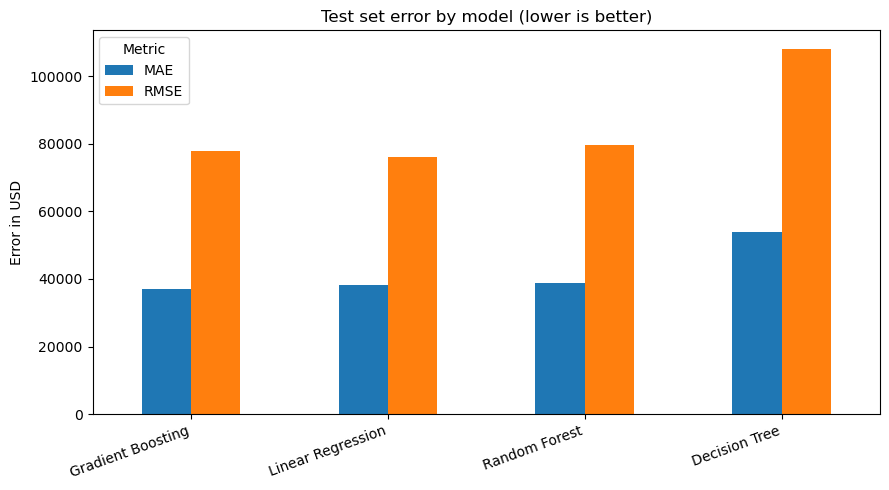

In [33]:
## Visualise the comparison
comparison.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', figsize=(9, 5))
plt.title('Test set error by model (lower is better)')
plt.xlabel('')
plt.ylabel('Error in USD')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

Gradient Boosting has the lowest MAE before tuning. Its MAE is about 2.5% lower than Linear
Regression. Random Forest is slightly worse than Linear Regression, while the single Decision
Tree performs the worst and has a negative R2 score.

Gradient Boosting is selected for tuning because it has the best MAE on the test set.


## 4.6 Hyperparameter Tuning

`RandomizedSearchCV` tests 10 randomly selected combinations using 3-fold cross-validation.
It is faster than trying every possible combination.

Five settings are tested:

| Setting | Values |
|---|---|
| `n_estimators` | 200, 300, 400 |
| `learning_rate` | 0.03, 0.05, 0.1 |
| `max_depth` | 3, 4, 5 |
| `min_samples_split` | 2, 10, 20 |
| `loss` | squared error, absolute error |

The search is scored using MAE because it is the main metric for this project.


In [34]:
## Settings to test
param_dist_gb = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 10, 20],
    'loss': ['squared_error', 'absolute_error']
}

from sklearn.model_selection import RandomizedSearchCV

gb = GradientBoostingRegressor(random_state=random_state)

rs_gb = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist_gb,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=random_state,
    n_jobs=-1,
    verbose=2
)

rs_gb.fit(x_train, y_train)

best_params = rs_gb.best_params_
best_gtree = rs_gb.best_estimator_

print()
print('Best parameters:', best_params)
print(f'Best cross validation MAE: USD {-rs_gb.best_score_:,.2f}')


Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': 4, 'loss': 'absolute_error', 'learning_rate': 0.1}
Best cross validation MAE: USD 33,769.09


In [35]:
## Show the combinations tested
cv_columns = [
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'param_min_samples_split',
    'mean_test_score',
    'std_test_score',
    'rank_test_score'
]

cv_results = pd.DataFrame(rs_gb.cv_results_)[cv_columns]

## Scikit-learn stores the MAE as a negative score
cv_results['mean_test_score'] = -cv_results['mean_test_score']
cv_results = cv_results.rename(columns={
    'mean_test_score': 'CV MAE (USD)',
    'std_test_score': 'Standard deviation',
    'rank_test_score': 'Rank'
})

cv_results.sort_values('Rank').round(4)


,param_n_estimators,param_learning_rate,param_max_depth,param_min_samples_split,CV MAE (USD),Standard deviation,Rank
9,300,0.10,4,10,33769.0886,757.4789,1
7,400,0.10,3,20,33859.8294,769.8537,2
5,400,0.05,4,10,33890.1931,811.6765,3
8,400,0.03,5,10,34016.1986,769.6871,4
2,300,0.05,3,20,34710.8730,799.3934,5
4,400,0.05,3,2,36211.2098,828.5373,6
3,300,0.03,4,2,36452.0778,994.6402,7
1,200,0.03,5,20,36649.7053,798.1634,8
0,400,0.05,5,10,36908.8057,723.9997,9
6,400,0.10,5,20,38088.7737,494.4870,10


In [36]:
## Evaluate the tuned model on the test set and compare it against the untuned version
y_pred_best = best_gtree.predict(x_test)

tuning_comparison = pd.DataFrame([
    {'Version': 'Gradient Boosting (default settings)',
     'MAE': mean_absolute_error(y_test, y_pred_gtree),
     'RMSE': root_mean_squared_error(y_test, y_pred_gtree),
     'R2': r2_score(y_test, y_pred_gtree)},
    {'Version': 'Gradient Boosting (tuned with RandomizedSearchCV)',
     'MAE': mean_absolute_error(y_test, y_pred_best),
     'RMSE': root_mean_squared_error(y_test, y_pred_best),
     'R2': r2_score(y_test, y_pred_best)},
])

mae_change = tuning_comparison['MAE'].iloc[1] - tuning_comparison['MAE'].iloc[0]
print('Change in MAE after tuning:', round(mae_change, 2), 'USD',
      f'({mae_change / tuning_comparison["MAE"].iloc[0] * 100:+.2f}%)')
print('A negative value means the error got smaller.')

tuning_comparison.round(2)

Change in MAE after tuning: -3107.67 USD (-8.37%)
A negative value means the error got smaller.


,Version,MAE,RMSE,R2
0,Gradient Boosting (default settings),37118.84,77713.36,0.36
1,Gradient Boosting (tuned with RandomizedSearchCV),34011.17,76916.30,0.37


Tuning reduced the test MAE from about USD 37,119 to USD 34,011, an improvement of about 8.4%.
The tuned Gradient Boosting model will be used as the final model.


# 5. Model Evaluation

## 5.1 Choice of evaluation metric

- **MAE** is the main metric because it gives the average error in dollars.
- **RMSE** gives more weight to very large errors.
- **R2** shows how much of the variation in salary is explained by the model.

Salary also depends on information that is not in the survey, so the prediction should be treated
as an estimate rather than an exact figure.


In [37]:
## Final results for all models
final_predictions = model_predictions.copy()
final_predictions['Gradient Boosting (tuned)'] = y_pred_best

final_rows = []

for name in final_predictions:
    y_pred = final_predictions[name]
    final_rows.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': root_mean_squared_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'R2': r2_score(y_test, y_pred)
    })

final_results = pd.DataFrame(final_rows)
final_results = final_results.sort_values('MAE').reset_index(drop=True)
final_results.round(2)


,Model,MAE,RMSE,MSE,R2
0,Gradient Boosting (tuned),34011.17,76916.30,5.916117e+09,0.37
1,Gradient Boosting,37118.84,77713.36,6.039366e+09,0.36
2,Linear Regression,38061.83,76154.22,5.799466e+09,0.38
3,Random Forest,38682.47,79761.83,6.361950e+09,0.32
4,Decision Tree,53803.68,108135.47,1.169328e+10,-0.25


## 5.2 Actual against predicted salary

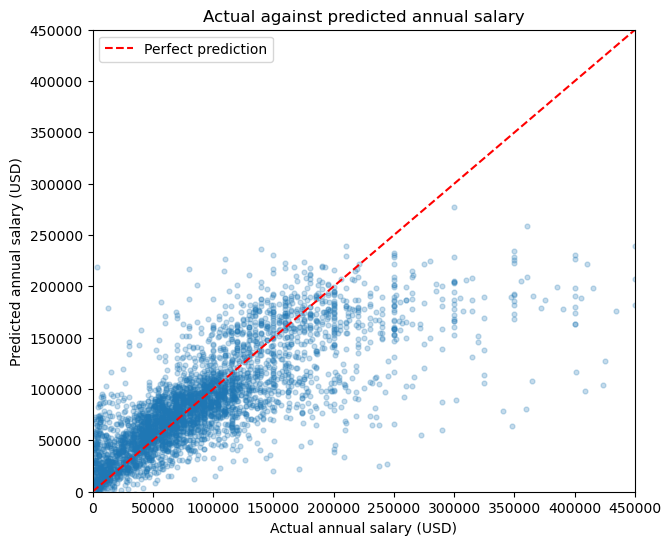

In [38]:
## Compare the actual and predicted salaries of the final model
scatter_limit = float(y_test.quantile(0.99))

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.25, s=12)
plt.plot([0, scatter_limit], [0, scatter_limit], color='red', linestyle='--', label='Perfect prediction')
plt.xlim(0, scatter_limit)
plt.ylim(0, scatter_limit)
plt.title('Actual against predicted annual salary')
plt.xlabel('Actual annual salary (USD)')
plt.ylabel('Predicted annual salary (USD)')
plt.legend()
plt.show()

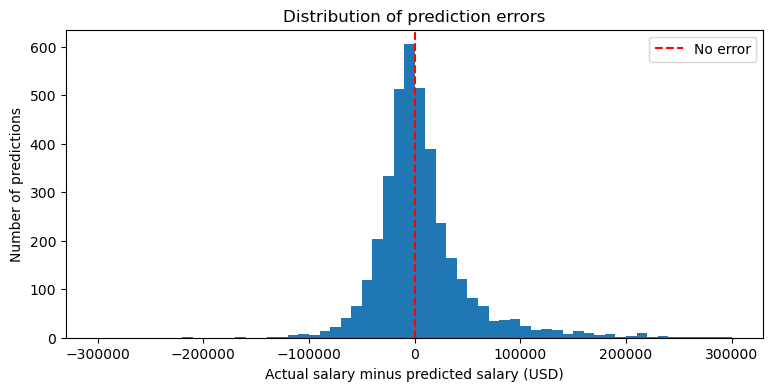

Average error: 11,557.96 USD
Median error:  -667.48 USD
Share of predictions that are too low: 49.04%


In [39]:
## Distribution of the prediction errors
residuals = y_test.to_numpy() - y_pred_best

plt.figure(figsize=(9, 4))
plt.hist(residuals, bins=60, range=(-300000, 300000))
plt.axvline(x=0, color='red', linestyle='--', label='No error')
plt.title('Distribution of prediction errors')
plt.xlabel('Actual salary minus predicted salary (USD)')
plt.ylabel('Number of predictions')
plt.legend()
plt.show()

print(f'Average error: {residuals.mean():,.2f} USD')
print(f'Median error:  {np.median(residuals):,.2f} USD')
print(f'Share of predictions that are too low: {(residuals > 0).mean() * 100:.2f}%')

Points closer to the red line have better predictions. The model follows the middle salary range
more closely but tends to under-predict the highest salaries.

The result should be used as a rough benchmark, especially for senior or highly paid users.


## 5.3 Where the model works and where it does not

In [40]:
## Check error across salary ranges
salary_range = pd.cut(
    y_test,
    bins=[0, 25000, 50000, 75000, 100000, 150000, 250000, np.inf],
    labels=['Under 25k', '25k to 50k', '50k to 75k', '75k to 100k',
            '100k to 150k', '150k to 250k', '250k and above'],
    right=False
)

error_table = pd.DataFrame({
    'Salary range': salary_range,
    'Absolute error': np.abs(residuals),
    'Actual salary': y_test.to_numpy()
})

error_by_range = error_table.groupby(
    'Salary range', observed=False
).agg({
    'Absolute error': ['size', 'mean'],
    'Actual salary': 'mean'
})

error_by_range.columns = [
    'Test records',
    'MAE',
    'Average actual salary'
]

error_by_range['MAE as percentage of average salary'] = (
    error_by_range['MAE'] /
    error_by_range['Average actual salary'] * 100
)

error_by_range.round(2)


,Test records,MAE,Average actual salary,MAE as percentage of average salary
Salary range,,,,
Under 25k,509,22747.31,11150.72,204.00
25k to 50k,586,17206.01,38641.65,44.53
50k to 75k,686,17908.35,62464.28,28.67
75k to 100k,601,17858.78,86872.37,20.56
100k to 150k,728,28534.35,120572.13,23.67
150k to 250k,517,46108.22,184035.95,25.05
250k and above,184,219164.42,389808.56,56.22


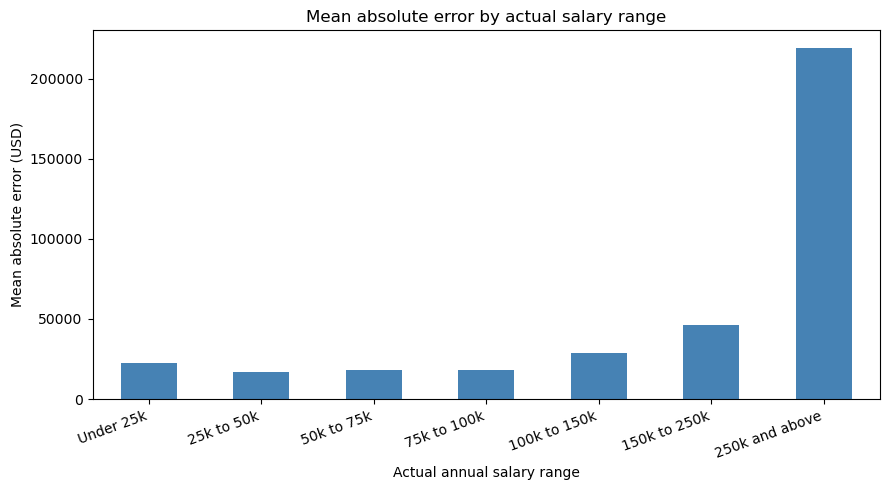

In [41]:
## Visualise the error across the salary range
error_by_range['MAE'].plot(kind='bar', figsize=(9, 5), color='steelblue')
plt.title('Mean absolute error by actual salary range')
plt.xlabel('Actual annual salary range')
plt.ylabel('Mean absolute error (USD)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

The model performs best in the middle salary ranges. Its percentage error is much larger for
salaries under USD 25,000 and above USD 250,000, so predictions in those ranges need more caution.


## 5.4 Which features drive the prediction

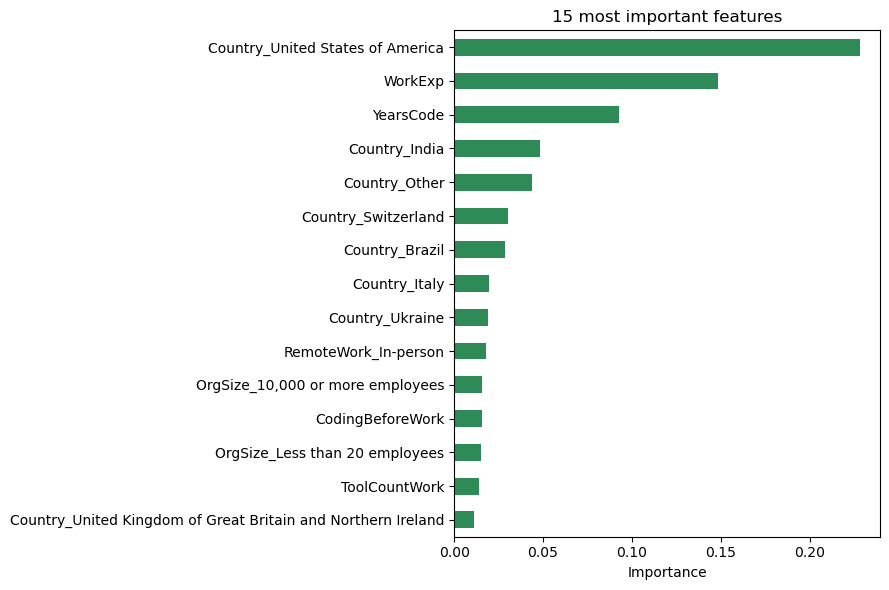

Country_United States of America                                0.2282
WorkExp                                                         0.1484
YearsCode                                                       0.0929
Country_India                                                   0.0480
Country_Other                                                   0.0436
Country_Switzerland                                             0.0304
Country_Brazil                                                  0.0287
Country_Italy                                                   0.0193
Country_Ukraine                                                 0.0189
RemoteWork_In-person                                            0.0179
OrgSize_10,000 or more employees                                0.0158
CodingBeforeWork                                                0.0156
OrgSize_Less than 20 employees                                  0.0148
ToolCountWork                                                   0.0137
Countr

In [42]:
## Show the features the final model relies on most
feature_importance = pd.Series(best_gtree.feature_importances_, index=x_train.columns)
feature_importance = feature_importance.sort_values(ascending=False).head(15)

feature_importance.sort_values().plot(kind='barh', figsize=(9, 6), color='seagreen')
plt.title('15 most important features')
plt.xlabel('Importance')
plt.ylabel('')
plt.tight_layout()
plt.show()

feature_importance.round(4)

Country and experience are among the most important features. This matches the earlier plots,
where salary differed strongly by country and generally increased with experience.


## 5.5 Conclusion

The final model is a tuned Gradient Boosting Regressor using 16 input features. It has the lowest
MAE of the models tested, at about USD 34,011.

The single Decision Tree performs poorly. Random Forest is much better than the single tree but is
still slightly worse than Linear Regression on MAE. Tuning improves Gradient Boosting by about
8.4% compared with its default settings.

The model is most useful for the middle salary ranges and well-represented countries. It is less
reliable for very low and very high salaries, and it does not include employer-specific details.



# 6. Saving the Model

In [45]:
## Save the model together with everything the web app needs to rebuild the same input columns
import joblib

model_package = {
    'model': best_gtree,
    'model_name': 'GradientBoostingRegressor (tuned with RandomizedSearchCV)',
    'col_x': col_x,
    'col_x_numeric': col_x_numeric,
    'col_x_categorical': col_x_categorical,
    'col_encoded': x.columns.tolist(),   ## The exact column order the model expects
    'col_options': col_options,          ## Fills the dropdowns in the web app
    'best_params': best_params,
    'test_mae': mean_absolute_error(y_test, y_pred_best),
    'test_rmse': root_mean_squared_error(y_test, y_pred_best),
    'test_r2': r2_score(y_test, y_pred_best),
}

joblib.dump(model_package, 'salary_model_8_0.pkl')

print('Saved salary_model_8_0.pkl')

Saved salary_model_8_0.pkl
